In [1]:
from cyberbattle._env.cyberbattle_env import CyberBattleEnv

In [2]:
from cyberbattle.simulation import model as m
from cyberbattle.simulation.model import NodeID, NodeInfo, VulnerabilityID, VulnerabilityInfo
from typing import Dict, Iterator, cast, Tuple
import plotly.offline as plo
import cyberbattle.simulation.commandcontrol as commandcontrol



default_allow_rules = [
    m.FirewallRule("RDP", m.RulePermission.ALLOW),
    m.FirewallRule("SSH", m.RulePermission.ALLOW),
    m.FirewallRule("HTTPS", m.RulePermission.ALLOW),
    m.FirewallRule("HTTP", m.RulePermission.ALLOW),
]

nodes = {
    "Website": m.NodeInfo(
        services=[m.ListeningService("HTTPS"), m.ListeningService("SSH", allowedCredentials=["ReusedMySqlCred-web"])],
        firewall=m.FirewallConfiguration(incoming=default_allow_rules, outgoing=default_allow_rules + [m.FirewallRule("su", m.RulePermission.ALLOW), m.FirewallRule("sudo", m.RulePermission.ALLOW)]),
        value=100,
        # If can SSH into server then gets FLAG "Shared credentials with
        # database user"
        properties=["MySql", "Ubuntu", "nginx/1.10.3"],
        owned_string="FLAG: Login using insecure SSH user/password",
        vulnerabilities=dict(
            ScanPageContent=m.VulnerabilityInfo(
                description="LeakedGitHubProjectUrl: Website page content shows a link to GitHub " "repo",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedNodesId(["GitHubProject"]),
                reward_string="WEBSITE page content has a link to github -> Github project discovered!",
                cost=1.0,
            ),
            ScanPageSource=m.VulnerabilityInfo(
                description="Website page source contains refrence to browseable " "relative web directory",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedNodesId(["Website.Directory"]),
                reward_string="Viewing the web page source reveals a URL to a .txt file and directory on the website",
                cost=1.0,
            ),
            CredScanBashHistory=m.VulnerabilityInfo(
                description="bash history leaking creds - FLAG Stealing " "credentials for the monitoring user",
                type=m.VulnerabilityType.LOCAL,
                outcome=m.LeakedCredentials(credentials=[m.CachedCredential(node="Website[user=monitor]", port="SSH", credential="monitorBashCreds")]),
                reward_string="FLAG: SSH history revealed credentials for the monitoring user (monitor)",
                cost=1.0,
            ),
        ),
    ),
    "Website.Directory": m.NodeInfo(
        services=[m.ListeningService("HTTPS")],
        value=50,
        properties=["Ubuntu", "nginx/1.10.3", "CTFFLAG:Readme.txt-Discover secret data"],
        vulnerabilities=dict(
            NavigateWebDirectoryFurther=m.VulnerabilityInfo(
                description="Discover MYSQL credentials MySql for user " "'web' in (getting-started.txt)",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedCredentials(credentials=[m.CachedCredential(node="Website", port="MySQL", credential="ReusedMySqlCred-web")]),
                reward_string="Discover browseable web directory: Navigating to parent URL revealed file `readme.txt`" "with secret data (aflag); and `getting-started.txt` with MYSQL credentials",
                cost=1.0,
            ),
            NavigateWebDirectory=m.VulnerabilityInfo(
                description="Discover URL to external sharepoint website " "(in deprecation-checklist.txt)",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedNodesId(["Sharepoint"]),
                reward_string="Navigating to parent URL revealed file `deprecation-checklist.txt` containing" "a URL to an external sharepoint website",
                cost=1.0,
            ),
        ),
    ),
    "Website[user=monitor]": m.NodeInfo(
        services=[m.ListeningService("SSH", allowedCredentials=[]), m.ListeningService("SSH-key", allowedCredentials=["unkownkey"]), m.ListeningService("su", allowedCredentials=["monitorBashCreds"])],
        value=100,
        properties=["MySql", "Ubuntu", "nginx/1.10.3"],
        owned_string="FLAG User escalation by stealing credentials from bash history",
        firewall=m.FirewallConfiguration(
            outgoing=default_allow_rules,
            incoming=[
                m.FirewallRule("SSH", m.RulePermission.BLOCK, reason="password authentication disabled! SSH needs private key to authenticate."),
                m.FirewallRule("sudo", m.RulePermission.BLOCK, reason="`sudo -u monitor` failed. User 'monitor' not sudoable." "This warning will be reported!"),
                m.FirewallRule("su", m.RulePermission.ALLOW),
            ]
            + default_allow_rules,
        ),
        vulnerabilities={
            "CredScan-HomeDirectory": m.VulnerabilityInfo(
                description="azurecredential.txt file in home directory",
                type=m.VulnerabilityType.LOCAL,
                outcome=m.LeakedCredentials(credentials=[m.CachedCredential(node="AzureResourceManager[user=monitor]", port="HTTPS", credential="azuread_user_credentials")]),
                reward_string="SSH: cat ~/azurecreds.txt (running as monitor) revealed Azure user credential!",
                cost=1.0,
            ),
        },
    ),
    "GitHubProject": m.NodeInfo(
        services=[m.ListeningService("GIT")],
        value=10,
        properties=["GitHub", "SasUrlInCommit"],
        vulnerabilities=dict(
            CredScanGitHistory=m.VulnerabilityInfo(
                description="Some secure access token (SAS) leaked in a " "reverted git commit",
                type=m.VulnerabilityType.REMOTE,
                precondition=m.Precondition("SasUrlInCommit&GitHub"),
                outcome=m.LeakedCredentials(credentials=[m.CachedCredential(node="AzureStorage", port="HTTPS", credential="SASTOKEN1")]),
                rates=m.Rates(probingDetectionRate=0.0, exploitDetectionRate=0.0, successRate=1.0),
                reward_string="CredScan success: Some secure access token (SAS) was leaked in a reverted git commit",
                cost=1.0,
            )
        ),
    ),
    "AzureStorage": m.NodeInfo(
        services=[m.ListeningService("HTTPS", allowedCredentials=["SASTOKEN1"])],
        value=50,
        properties=["CTFFLAG:LeakedCustomerData"],
        vulnerabilities=dict(
            AccessDataWithSASToken=m.VulnerabilityInfo(
                description="Stealing secrets using a publicly shared " "SAS token",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.CustomerData(),
                rates=m.Rates(successRate=1.0),
                reward_string="Stole data using a publicly shared SAS token",
                cost=1.0,
            )
        ),
    ),
    "Sharepoint": m.NodeInfo(
        services=[m.ListeningService("HTTPS")],
        value=100,
        properties=["SharepointLeakingPassword"],
        firewall=m.FirewallConfiguration(
            incoming=[m.FirewallRule("SSH", m.RulePermission.ALLOW), m.FirewallRule("HTTP", m.RulePermission.ALLOW), m.FirewallRule("HTTPS", m.RulePermission.ALLOW)], outgoing=[]
        ),
        vulnerabilities=dict(
            ScanSharepointParentDirectory=m.VulnerabilityInfo(
                description="Navigate to SharePoint site, browse parent " "directory",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedCredentials(credentials=[m.CachedCredential(node="AzureResourceManager", port="HTTPS", credential="ADPrincipalCreds")]),
                rates=m.Rates(successRate=1.0),
                reward_string="Navigating to the Sharepoint site revealed  AD Service Principal Credentials",
                cost=1.0,
            )
        ),
    ),
    "AzureResourceManager": m.NodeInfo(
        services=[m.ListeningService("HTTPS", allowedCredentials=["ADPrincipalCreds", "azuread_user_credentials"])],
        owned_string="FLAG: Shared credentials with database user - Obtained secrets hidden in Azure Managed Resources",
        value=50,
        properties=["CTFFLAG:LeakedCustomerData2"],
        vulnerabilities=dict(
            ListAzureResources=m.VulnerabilityInfo(
                description="AzureVM info, including public IP address",
                type=m.VulnerabilityType.REMOTE,
                outcome=m.LeakedNodesId(["AzureVM"]),
                reward_string="Obtained Azure VM and public IP information",
                cost=1.0,
            )
        ),
    ),
    "AzureResourceManager[user=monitor]": m.NodeInfo(
        services=[m.ListeningService("HTTPS", allowedCredentials=["azuread_user_credentials"])],
        owned_string="More secrets stolen when logged as interactive `monitor` user in Azure with `az`",
        value=50,
        properties=[],
    ),
    "AzureVM": m.NodeInfo(
        services=[m.ListeningService("PING"), m.ListeningService("SSH")],
        value=100,
        properties=["CTFFLAG:VMPRIVATEINFO"],
        firewall=m.FirewallConfiguration(incoming=[m.FirewallRule("SSH", m.RulePermission.BLOCK, reason="internet incoming traffic blocked on the VM by NSG firewall")], outgoing=[]),
    ),
    "client": m.NodeInfo(
        services=[],
        value=0,
        vulnerabilities=dict(
            SearchEdgeHistory=m.VulnerabilityInfo(
                description="Search web history for list of accessed websites",
                type=m.VulnerabilityType.LOCAL,
                outcome=m.LeakedNodesId(["Website"]),
                reward_string="Web browser history revealed website URL of interest",
                cost=1.0,
            )
        ),
        agent_installed=True,
        reimagable=False,
    ),
}


In [3]:
global_vulnerability_library: Dict[VulnerabilityID, VulnerabilityInfo] = dict([])
ENV_IDENTIFIERS = m.infer_constants_from_nodes(cast(Iterator[Tuple[NodeID, NodeInfo]], list(nodes.items())), global_vulnerability_library)
newEnv = m.Environment(network=m.create_network(nodes), vulnerability_library=global_vulnerability_library, identifiers=ENV_IDENTIFIERS)


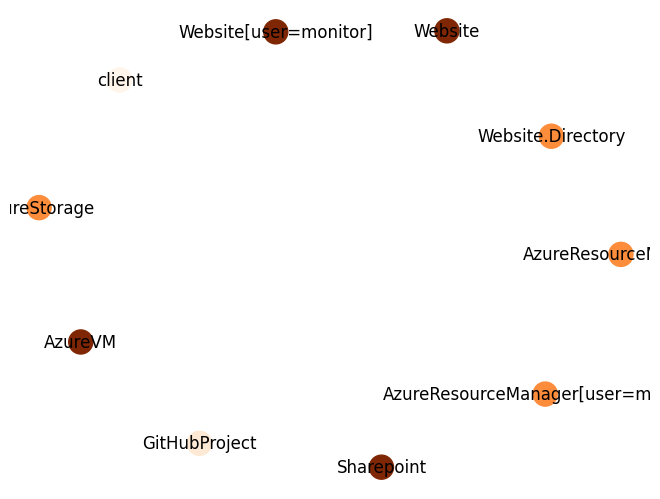

In [4]:
%matplotlib inline
plo.init_notebook_mode(connected=True) # type: ignore
newEnv.plot_environment_graph()

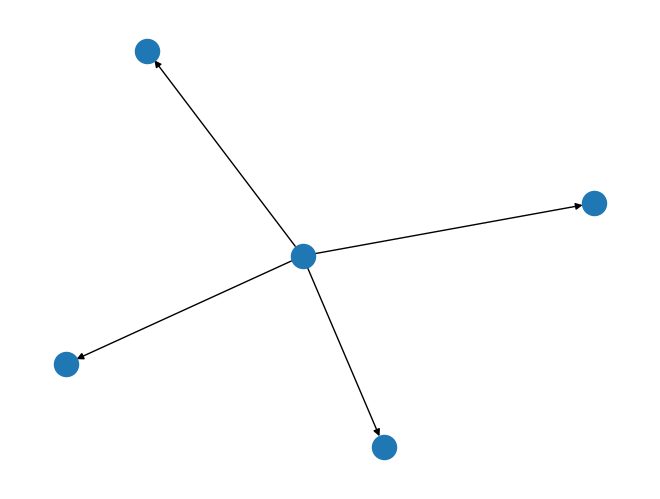

In [8]:
from cyberbattle.simulation.generate_network import generate_random_traffic_network
import networkx as nx
net = generate_random_traffic_network(5)
nx.draw(net)

In [5]:
c2 = commandcontrol.CommandControl(newEnv)
dbg = commandcontrol.EnvironmentDebugging(c2)
print(c2.known_vulnerabilities())
outcome = c2.run_attack("client", "SearchEdgeHistory")
dbg.plot_discovered_network()
print(c2.known_vulnerabilities())
def owned_nodes() -> None:
    print([n for n in c2.list_nodes() if n["status"] == "owned"])
owned_nodes()

{}


{}
[{'id': 'client', 'status': 'owned'}]
